In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
import coulomb as cb
    
exp_data = pd.read_csv(f'../data/garsany_et_al_2018/Garsany2018-gz.csv', sep=';', decimal=',')
exp_data = exp_data[exp_data.cell_id != 'GORE']
cells = exp_data.cell_id.unique()
for cell in cells: 
    exp_data.loc[exp_data.cell_id  == cell, 'case'] = exp_data.loc[exp_data.cell_id  == cell, ['T_stack', 'rh_ca', 'rh_an', 'p_ca_out']].sum(axis=1)
case_list = [1,2,3]
exp_data['case'] = exp_data['case'].map(dict(zip(exp_data['case'].unique(),case_list)))
exp_data

,i,U,T_stack,rh_ca,rh_an,st_ca,st_an,x_o2_ca,p_ca_out,p_an_out,figure,cell_id,hfr,case
0,0.0113,0.9005,353.15,1.0,1.0,100.884956,100.884956,0.2,101000,101000,7a,LSC Nafion,NaN,1
1,0.0198,0.8797,353.15,1.0,1.0,57.575758,57.575758,0.2,101000,101000,7a,LSC Nafion,NaN,1
2,0.0594,0.8499,353.15,1.0,1.0,19.191919,19.191919,0.2,101000,101000,7a,LSC Nafion,NaN,1
3,0.1876,0.8012,353.15,1.0,1.0,6.076759,6.076759,0.2,101000,101000,7a,LSC Nafion,0.000006,1
4,0.4047,0.7396,353.15,1.0,1.0,2.816901,2.816901,0.2,101000,101000,7a,LSC Nafion,0.000006,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,1.6031,0.6016,353.15,1.0,1.0,2.000000,2.000000,0.2,150000,150000,8a,SSC Aquivion,0.000005,3
92,1.8349,0.5505,353.15,1.0,1.0,2.000000,2.000000,0.2,150000,150000,8a,SSC Aquivion,0.000005,3
93,2.0216,0.5006,353.15,1.0,1.0,2.000000,2.000000,0.2,150000,150000,8a,SSC Aquivion,0.000006,3
94,2.1860,0.4510,353.15,1.0,1.0,2.000000,2.000000,0.2,150000,150000,8a,SSC Aquivion,0.000006,3


In [3]:
def compute_ui_curve(cell, case): 
        case_exp_data = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id == cell.name)]
        current_density = np.maximum(1,1e4*case_exp_data['i'].values)
        cathode_conditions = cb.OperatingConditions(
            inlet_temperature = case_exp_data['T_stack'].values,
            inlet_relative_humidity=case_exp_data['rh_ca'].values,
            outlet_pressure=case_exp_data['p_ca_out'].values,
            dry_o2_mole_fraction=0.21,
            dry_h2_mole_fraction=0,
            stoichiometry=case_exp_data['st_ca'].values,
        )
        anode_conditions = cb.OperatingConditions(
            inlet_temperature = case_exp_data['T_stack'].values,
            inlet_relative_humidity=case_exp_data['rh_an'].values,
            outlet_pressure=case_exp_data['p_an_out'].values,
            dry_o2_mole_fraction=0,
            dry_h2_mole_fraction=1,
            stoichiometry=case_exp_data['st_an'].values,
        )

        cell.set_conditions(case_exp_data['T_stack'].values, 
                                 current_density,cathode_conditions, anode_conditions)

        
        cell.calculate_heat_transfer_resistance()
        mea_temperature = fuel_cell.temperature + (cell.current_density * 0.7) * cell.thermal_resistance
        cell.set_mea_temperature(mea_temperature)
       
        cell.calculate_water_transport()
        # s_ca_cl = fuel_cell.ca.cl.water_saturation
        # fuel_cell.membrane.water_content = fuel_cell.membrane.water_content * (1-s_ca_cl) + s_ca_cl * 22
        # fuel_cell.ca.cl.water_content = fuel_cell.ca.cl.water_content * (1-s_ca_cl) + s_ca_cl * 22
        cell.calculate_reactant_concentration_at_cl()
        
       # fuel_cell.solve_transport() 
        return cell.cell_voltage()

In [4]:
class HydrogenPermeationModel:
    def __init__(self): 
        pass 

    def permeation_flux(self,
                        membrane_thickness: float,
                        partial_pressure_h2: float,
                        temperature: float,
                        pressure_difference: float,
                        water_vol_fraction: float
        ) -> float:
        D_h2_w = 2.205e-9
        S_h2_w = 7.12e-6
        k_l_mb = 1.6e-18
        mu_w = cb.water.water_dynamic_viscosity(temperature)
        h2_permeability = (D_h2_w + water_vol_fraction * k_l_mb / mu_w * pressure_difference) * S_h2_w
        return h2_permeability * 1e-3 * partial_pressure_h2 / membrane_thickness
    
class ChannelGasResistanceModel: 
    def __init__(self, A_cell): 
        self.A_cell = A_cell

    def total_resistance(self, channel, diffusion_coefficient, volume_flow_rate): 
        return self.A_cell / volume_flow_rate / 2


@dataclass 
class CatalystLayerIonomerModel: 
    density: float = 2004 
    equivalent_weight: float = 952. 
    hydrated_proton_conductivity: float = 11 # S/m
    proton_conductivity_exponent: float = 2.7

    def o2_film_resistance(self, water_content, temperature= 353.15):
        # Linear regression of data from Jinnouchi et al. (2021), neglecting bulk diffusion.
        # Activation energy obtained by Kudo et al. (2006).
        return 1.14698e-10 * (water_content/14) ** 0.708 #* cb.calculate_arrhenius_term(-24e6, temperature, 353.15)

    def proton_conductivity(self, relative_humidity, water_content, temperature):
        return self.hydrated_proton_conductivity * (water_content/14.) ** (self.proton_conductivity_exponent) * cb.calculate_arrhenius_term(11e6, temperature, 353.15) # Following measurements of Hutapea et al. (2023)

@dataclass
class PorousLiquidTransportModel: 
    critical_damkholer: float = 1.
    dry_wet_transition_parameter: float = 10

    def vapor_transport_resistance(self, cell_side): 
        return cell_side.calculate_gas_transport_resistance('h2o')
    
    def calculate_damkholer_number(self, cell_side, water_injection_flux): 
        cl_sat_concentration = cell_side.cl.get_saturation_concentration()
        ch_vapor_concentration = cell_side.ch.get_vapor_concentration()
        max_vapor_removal_flux = (cl_sat_concentration - ch_vapor_concentration) / cell_side.h2ov_transport_resistance
        return water_injection_flux / max_vapor_removal_flux
        
    def calculate_water_saturation(self, cell_side, water_injection_flux): 
        #damkholer = self.calculate_damkholer_number(cell_side, water_injection_flux)
        cl_sat_concentration = cell_side.cl.get_saturation_concentration()
        ch_vapor_concentration = cell_side.ch.get_vapor_concentration()
        max_vapor_removal_flux = (cl_sat_concentration - ch_vapor_concentration) / cell_side.h2ov_transport_resistance
        #return self.wet_saturation *  cb.sigmoid(water_injection_flux, max_vapor_removal_flux * self.critical_damkholer, self.dry_wet_transition_parameter)
        return (np.maximum(water_injection_flux-max_vapor_removal_flux * self.critical_damkholer,1e-12) / cell_side.gdl.absolute_permeability) ** self.dry_wet_transition_parameter

In [5]:
def create_fuel_cell(params, cell): 

    ORRkinetics=cb.ElectrochemicalReaction(
                    reference_exchange_current_density=params['i0-c'],
                    reaction_order=params['gamma-c'], 
                    activation_energy=67e6, 
                    reference_activity=1.01325e5,
                    reference_temperature=353.15,
                    number_of_electrons=2,
                    charge_transfer_coeff=0.5
                )
    
    IonomerAquivionD83=cb.CatalystLayerIonomerModel(equivalent_weight=830.,
        hydrated_proton_conductivity=params['AquivionD83-06-cl-proton-cond'],
        proton_conductivity_rh_exponent=0, 
        proton_conductivity_water_content_exponent=params['AquivionD83-06-cl-proton-cond-exp'],
        hydrated_o2_diffusion=params['AquivionD83-06-o2-diff'],
        o2_diffusion_exponent=params['AquivionD83-06-cl-o2-diff-exp'])
    
    IonomerNafionLQ1115=cb.CatalystLayerIonomerModel(equivalent_weight=1100.,
        hydrated_proton_conductivity=params['NafionLQ1115-cl-proton-cond'],
        proton_conductivity_rh_exponent=0,
        proton_conductivity_water_content_exponent=params['NafionLQ1115-cl-proton-cond-exp'], 
        hydrated_o2_diffusion=params['NafionLQ1115-o2-diff'], 
        o2_diffusion_exponent=params['NafionLQ1115-cl-o2-diff-exp'])

    AquivionCL = cb.CatalystLayer(
        platinum_loading=0.31e-2, 
        thickness=8e-6, 
        ionomer=IonomerAquivionD83,
        reaction=ORRkinetics,
        ecsa=61e3, 
        ionomer_to_carbon_ratio=0.95,
        pore_diameter=params['AquivionD83-06-pore-diameter'],
        catalyst_platinum_weight_percent=0.5, 
        thermal_conductivity=0.25,
        carbon_agglomerate_radius=100e-9,
        absolute_permeability=params['Aquivion-cl-K-abs'],
        contact_angle=95.,
        omega_PtO=0) 

    NafionCL = cb.CatalystLayer(
        platinum_loading=0.31e-2, 
        thickness=7.8e-6, 
        ionomer=IonomerNafionLQ1115,
        reaction=ORRkinetics,
        ecsa=65e3, 
        ionomer_to_carbon_ratio=0.95,
        carbon_agglomerate_radius=100e-9,
        pore_diameter=params['NafionLQ1115-pore-diameter'],
        catalyst_platinum_weight_percent=0.5, 
        absolute_permeability=params['Nafion-cl-K-abs'],
        contact_angle=95.,
        thermal_conductivity=0.25,
        omega_PtO=0) 

    GDL3Mca = cb.PorousLayer(
        thickness=236e-6,
        effective_gas_diffusion_ratio=params['3M-Deff-ratio'], 
        absolute_permeability=params['Kabs'], 
        thermal_conductivity=1./params['kth-gdl'],
        porosity=0.6,
        contact_angle=120.)

    GDL3Man = cb.PorousLayer(
        thickness=266e-6,
        effective_gas_diffusion_ratio=params['3M-Deff-ratio'],
        thermal_conductivity=1./params['kth-gdl'],
        absolute_permeability=params['Kabs'], 
        porosity=0.6,
        contact_angle=120.) 
    
    NafionHP = cb.Membrane(
        dry_thickness=20.3e-6, 
        conductivity_correction=params['NafionHP-conductivity-correction'],
        conductivity_exp=params['NafionHP-conductivity-exp'],
        water_balance_model=cb.MembraneWaterBalanceModel(
            reference_water_chemical_diffusion_coefficient=params['Nafion-memb-diff'],
            reference_absorption_coefficient=params['Nafion-memb-abs-constant'] if cell == 'LSC Nafion' else params['Aquivion-memb-abs-constant'])
    )
    fc = cb.FuelCell(
        electrical_resistance=params['elec-resistance'],
        cell_area = 10e-4, 
        cell_number = 1, 
        ca = cb.FuelCellSide(
            cl=NafionCL if cell=='LSC Nafion' else AquivionCL, has_mpl=False, gdl=GDL3Mca,  
            ch=cb.GasFlowChannel(
                reactant='o2',
                height=1e-3, 
                length=10e-4/2e-3,
                n_parallel=1,
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'], B_ch=params['B_ch'])
            ),
            liq_transport_model=cb.DarcyLiquidTransportModel(
                dry_wet_transition_parameter=params['wet-transition'],
            ),
            thermal_contact_resistance=2e-4,
        ),
        an = cb.FuelCellSide(
            cl=NafionCL, has_mpl=False, gdl=GDL3Man,
            ch=cb.GasFlowChannel(
                reactant='h2',
                height=1e-3, 
                length=10e-4/2e-3,
                n_parallel=1,
                transport_resistance_model = cb.ChannelGasResistanceModel(A_ch=params['A_ch'],B_ch=params['B_ch'])
            ),
            thermal_contact_resistance=2e-4,
        ),
        membrane = NafionHP
    )
    fc.name=cell
    return fc

array([0.9005, 0.8797, 0.8499, 0.8012, 0.7396, 0.6973, 0.6398, 0.5997,
       0.5493, 0.4999, 0.4495, 0.4005, 0.    , 0.    , 0.    , 0.0614,
       0.0558, 0.0545, 0.0536, 0.054 , 0.0547, 0.056 , 0.0582, 0.0606,
       0.8976, 0.8752, 0.8491, 0.8011, 0.7396, 0.7009, 0.639 , 0.6003,
       0.5489, 0.4997, 0.4494, 0.4005, 0.    , 0.    , 0.    , 0.0514,
       0.0423, 0.0412, 0.0411, 0.0413, 0.0423, 0.0439, 0.0471, 0.051 ,
       0.8981, 0.8769, 0.8478, 0.8007, 0.7371, 0.6991, 0.6401, 0.5999,
       0.5497, 0.5008, 0.4501, 0.4011, 0.    , 0.    , 0.129 , 0.103 ,
       0.0886, 0.0851, 0.0834, 0.0868, 0.0903, 0.0946, 0.099 , 0.105 ,
       0.8994, 0.8796, 0.8505, 0.8002, 0.7406, 0.698 , 0.6392, 0.5997,
       0.5501, 0.4998, 0.451 , 0.4012, 0.    , 0.    , 0.121 , 0.0964,
       0.0834, 0.0799, 0.0816, 0.0842, 0.0899, 0.0946, 0.101 , 0.106 ,
       0.9004, 0.8819, 0.8523, 0.8017, 0.7409, 0.7016, 0.6414, 0.6013,
       0.5509, 0.5002, 0.451 , 0.4008, 0.    , 0.    , 0.0688, 0.0575,
      

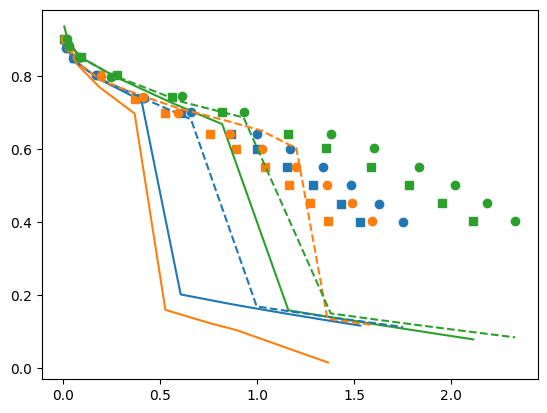

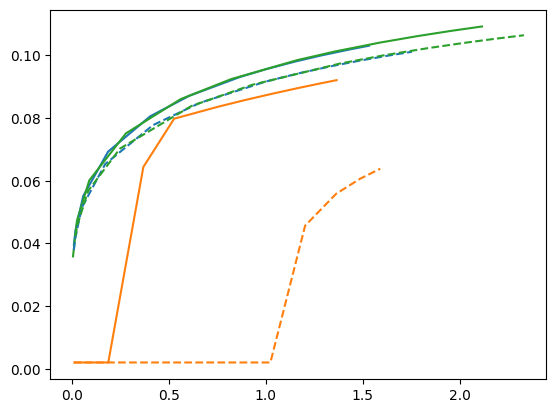

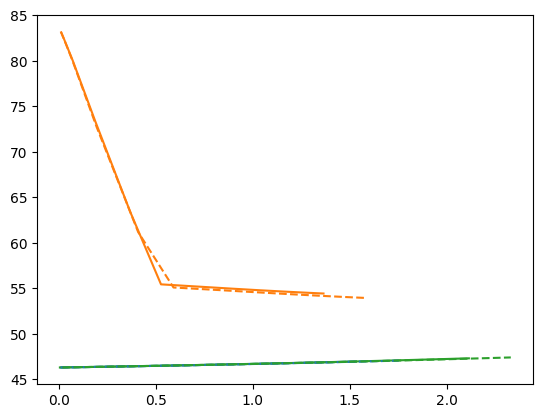

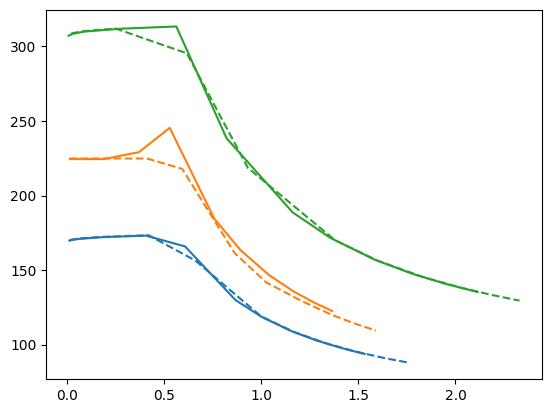

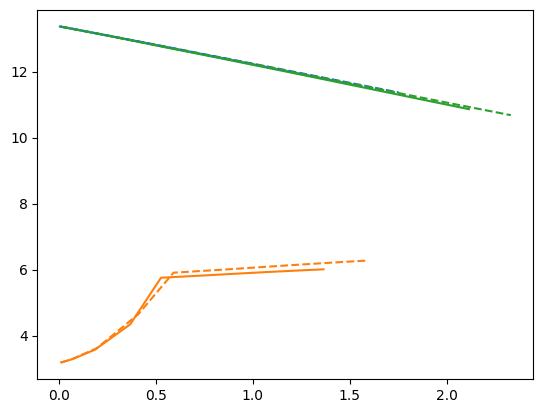

In [6]:

def h(params): 
    fuel_cells = {cell: create_fuel_cell(params,  cell) for cell in cells}
    return np.concatenate(
         [compute_ui_curve(fuel_cells[cell], case) for case in case_list for cell in cells if case in exp_data[exp_data.cell_id == cell].case.unique()]
    )
exp_voltage_list = np.concatenate(
         [exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id==cell), 'U'] for case in case_list for cell in cells if case in exp_data[exp_data.cell_id == cell].case.unique()]
    )

def h2(params): 
    res_list = []
    fuel_cells = {cell: create_fuel_cell(params,  cell) for cell in cells}
    for case in case_list: 
        for cell in cells: 
            if case in exp_data[exp_data.cell_id == cell].case.unique(): 
                V_sim = compute_ui_curve(fuel_cells[cell], case)
                hfr_sim = 1e4*fuel_cells[cell].high_frequency_resistance() * (1-np.isnan(exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id==cell), 'hfr']))
                res_list += [V_sim, hfr_sim]
    return np.concatenate(res_list)
exp_res_list = []
for case in case_list: 
        for cell in cells: 
            if case in exp_data[exp_data.cell_id == cell].case.unique(): 
                V_exp = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id==cell), 'U']
                hfr_exp = np.nan_to_num(1e4*exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id==cell), 'hfr'],0)
                exp_res_list += [V_exp, hfr_exp]
exp_res_list = np.concatenate(exp_res_list)


model = cb.ParameterEstimationSteadyState(h2, {'AquivionD83-06-cl-proton-cond-exp': 1.85,
        'AquivionD83-06-pore-diameter':120e-9, 
        'NafionLQ1115-pore-diameter':120e-9, 
        'i0-c': 3.82e-4, 
        'gamma-c': 0.54,
        'NafionLQ1115-cl-proton-cond-exp':2.41, 
        'NafionHP-conductivity-exp': 1, 
        'Aquivion-cl-K-abs': 1e-13, 
        'Nafion-cl-K-abs': 1e-13,
        'Nafion-memb-diff': 4.3e-10,
        'NafionLQ1115-cl-proton-cond':22.1, 
        'AquivionD83-06-cl-proton-cond-exp': 3.33,
        'AquivionD83-06-cl-proton-cond': 135,
        'NafionLQ1115-cl-o2-diff-exp': 0.7,
        'AquivionD83-06-cl-o2-diff-exp':0.7,
        'elec-resistance':40e-7,
        'NafionHP-conductivity-correction': 1.12e+00, 
        'Nafion-memb-abs-constant': 10e-6, 
        'Aquivion-memb-abs-constant': 2e-5, 
        'NafionLQ1115-o2-diff': 4e-10,
        'AquivionD83-06-o2-diff': 8.65e-10,
        '3M-Deff-ratio': 0.338,  
        'wet-transition': 0.2, 
        'B_ch': 1, 
        'A_ch': 1,  
        'kth-gdl':0.5,
        'Kabs': 1e-12
        })

'''
------------------------------
differential_evolution step 202: f(x)= 0.00020593796258720597
------------------------------
RMSE : 14.4 mV
AquivionD83-06-cl-proton-cond (1, 200) 1.35e+02
NafionLQ1115-cl-proton-cond (1, 200) 2.21e+01
AquivionD83-06-cl-proton-cond-exp (1, 4) 3.33e+00
NafionLQ1115-cl-proton-cond-exp (1, 4) 2.41e+00
AquivionD83-06-pore-diameter (1e-09, 2e-07) 4.94e-09
NafionLQ1115-pore-diameter (1e-09, 2e-07) 3.47e-08
AquivionD83-06-cl-o2-diff-exp (0.5, 2) 1.66e+00
NafionLQ1115-cl-o2-diff-exp (0.5, 2) 8.61e-01
NafionHP-conductivity-correction (0.5, 2) 1.78e+00
NafionHP-conductivity-exp (1, 2) 1.04e+00
Nafion-memb-abs-constant (1e-06, 0.0001) 4.59e-06
Aquivion-memb-abs-constant (1e-06, 0.0001) 1.99e-05
NafionLQ1115-o2-diff (1e-12, 1e-09) 1.88e-10
AquivionD83-06-o2-diff (1e-12, 1e-09) 8.65e-10
3M-Deff-ratio (0.15, 0.5) 3.38e-01
i0-c (1e-05, 0.001) 3.82e-04
elec-resistance (2e-06, 6e-06) 3.95e-06
A_ch (0.0001, 2) 1.56e-01
B_ch (0.0001, 2) 1.56e-02
wet-transition (0.0, 0.4) 3.57e-01
kth-gdl (0.05, 5) 5.00e-02
------------------------------
'''

for i_cell, cell in enumerate(['LSC Nafion', 'SSC Aquivion']): 
    for k, case in enumerate(case_list): 
        fuel_cell = create_fuel_cell(model.p, cell)
        U_sim = compute_ui_curve(fuel_cell, case)
        case_exp_data = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id == cell)]

        plt.figure(1)
        plt.plot(fuel_cell.current_density/1e4, U_sim, 'C{}-'.format(k) + ('-' if i_cell == 1 else ''))
        plt.plot(case_exp_data['i'].values, case_exp_data['U'].values, 'C{}'.format(k) + ('s' if i_cell == 0 else 'o'))
        plt.figure(2)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.ca.gdl.water_saturation, 'C{}-'.format(k) + '-' if i_cell == 1 else '')
        plt.figure(3)
        plt.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.high_frequency_resistance(), 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case )
        plt.figure(4)
        plt.plot(fuel_cell.current_density/1e4,fuel_cell.ca.calculate_gas_transport_resistance('h2o'), 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case )
        plt.figure(5)
        plt.plot(fuel_cell.current_density/1e4,fuel_cell.membrane.water_content, 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case )
exp_res_list

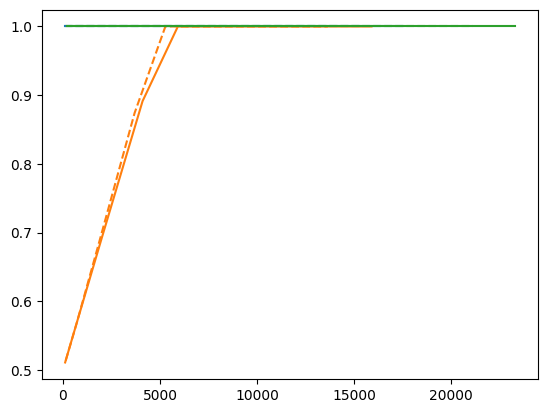

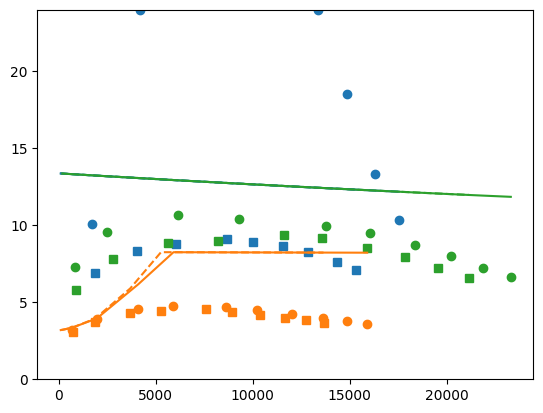

In [14]:
model.p['3M-Deff-ratio'] = 0.1
model.p['B_ch'] = 1e-0
model.p['A_ch'] = 3e-0
model.p['kth-gdl'] = .1
for i_cell, cell in enumerate(['LSC Nafion', 'SSC Aquivion']): 
    for k, case in enumerate(case_list): 
        fuel_cell = create_fuel_cell(model.p, cell)
       
        U_sim = compute_ui_curve(fuel_cell, case)
        case_exp_data = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id == cell)]
        S_exp = fuel_cell.membrane.dry_thickness / (case_exp_data['hfr']-39e-7) /  cb.calculate_arrhenius_term(10e6, 353.15, 303.15)
        plt.figure(1)
        #plt.plot(fuel_cell.current_density,S_exp ,'C{}'.format(k) + ('s' if i_cell == 0 else 'o'))
        #plt.plot(fuel_cell.current_density, fuel_cell.ca.liquid_flux,'C{}-'.format(k) + ('-' if i_cell == 0 else ''))
        plt.plot(fuel_cell.current_density, fuel_cell.ca.ch.get_vapor_concentration()/fuel_cell.ca.cl.get_saturation_concentration() + np.minimum(fuel_cell.h2o_production, fuel_cell.ca.max_water_vapor_removal()) * 
                 fuel_cell.ca.h2ov_transport_resistance / fuel_cell.ca.cl.get_saturation_concentration(), 'C{}-'.format(k) + ('-' if i_cell == 0 else ''))
        plt.figure(2)
        s = fuel_cell.ca.gdl.water_saturation
        plt.plot(fuel_cell.current_density,(S_exp + 0.326) ** (2./3) / 0.539 * 1.2, 'C{}'.format(k) + ('s' if i_cell == 0 else 'o'))
        plt.plot(fuel_cell.current_density,0.5*(
                (fuel_cell.membrane.equilibrium_water_content(fuel_cell.ca.ch.get_vapor_concentration()/fuel_cell.ca.cl.get_saturation_concentration() +
                                                              fuel_cell.h2o_production * fuel_cell.ca.h2ov_transport_resistance / fuel_cell.ca.cl.get_saturation_concentration())
                                                              ) + 
                 fuel_cell.membrane.equilibrium_water_content(fuel_cell.an.ch.get_vapor_concentration()/fuel_cell.an.cl.get_saturation_concentration())), 'C{}-'.format(k) + ('-' if i_cell == 0 else ''))
        plt.ylim([0,24])

In [15]:
model.set_unknown_params(
        [
        ('AquivionD83-06-cl-proton-cond', (1, 200), True, r'$\sigma_{Aquivion}$'),
        ('NafionLQ1115-cl-proton-cond', (1,200), True, r'$\sigma_{Nafion}$'),
        ('AquivionD83-06-cl-proton-cond-exp', (2, 4), True, r'$m\sigma_{Aquivion}$'),
        ('NafionLQ1115-cl-proton-cond-exp', (2,4), True, r'$m\sigma_{Nafion}$'),
        ('AquivionD83-06-pore-diameter', (1e-9, 200e-9), True, r'$dp_{Aquivion}$'),
        ('NafionLQ1115-pore-diameter', (1e-9, 200e-9), True, r'$dp_{Nafion}$'),
        ('AquivionD83-06-cl-o2-diff-exp', (0.5, 2), True, r'$\sigma_{Aquivion}$'),
        ('NafionLQ1115-cl-o2-diff-exp', (.5,2), True, r'$\sigma_{Nafion}$'),
        ('NafionHP-conductivity-correction', (0.5,5), True, '$k_{cond}$'),
        ('NafionHP-conductivity-exp', (1,2), True, '$m_{k}$'),
        ('Nafion-memb-abs-constant', (1e-6,1e-4), True, '$k_{abs}$'),
        ('Aquivion-memb-abs-constant', (1e-6,1e-4), True, '$k_{abs,Aq}$'),
        ('NafionLQ1115-o2-diff', (1e-12,10e-10), True, '$D_{O2,Nafion}$'),
        ('AquivionD83-06-o2-diff', (1e-12,10e-9), True, '$D_{O2,Aquivion}$'),
        ('3M-Deff-ratio', (0.15,0.5), True, '$D_{eff}/D$'),
        ('Nafion-memb-diff', (1e-10,10e-10), True, '$D_{\lambda}$'),
        ('i0-c',(1e-5,1e-3), False, '$i0_c$'),
        #('memb-thickness', (20e-6, 25e-6), True, '$t_m$'), 
        ('elec-resistance', (20e-7,60e-7), True, '$R_{elec}$'),
        
        ('A_ch', (0, 2), True, '$A_{ch}$'),
        ('B_ch', (0, 2), True, '$B_{ch}$'),
        #('ionomer-vol-fraction', (0.15,0.4), True, r'$\varepsilon_{ion}$'),
        ('Kabs', (1e-13,1e-11), False, '$K_{l}$'),
        ('Aquivion-cl-K-abs', (1e-14,1e-12), False, '$K_{l}$'),
        ('Nafion-cl-K-abs', (1e-14, 1e-12), False, '$K_{l}$'),
        #('wet-saturation', (0.1,0.5), True, '$s_{wet}$'),
        ('wet-transition', (0., 0.4), True, '$alpha_{wet}$'),
        #('critical-damkholer', (0.8,2), True, '$Da_{w,cr}$'),
        ('kth-gdl', (1./5,1./0.03), True, '$k_{GDL}$'),
        #('R-ch-correction', (0.,1.), True, '$R_{ch}$'),
        
        #('ionomer-vol-fraction', (0.1,.5), True, '$\epsilon_{ion}$'),
        #('E-act-ca', (50e3, 100e3), True, '$E_{act, ca}$'),
        #('omega-PtO', (1e6, 10e6), True, '$\omega_{PtO}$'),
        #('memb-cond-corr', (0.1,10), True,'$f_{mb}$'),
        #('memb-water-diff', (1e-10, 40e-10), True, '$D_{\lambda}$'),
        #('memb-abs-constant', (1e-7, 1e-4), False, '$k_{abs}$'),
        ]
    )


In [16]:

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=6,  
                                                                                                         check_samples=True,
                                                                                                         y_exp=exp_res_list, 
                                                                                                         res_limit=0.02)


Number of valid samples: 21


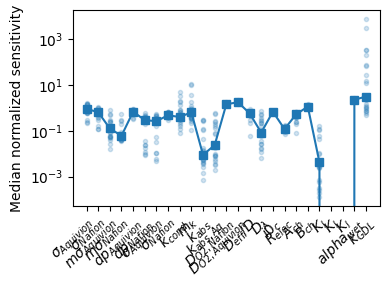

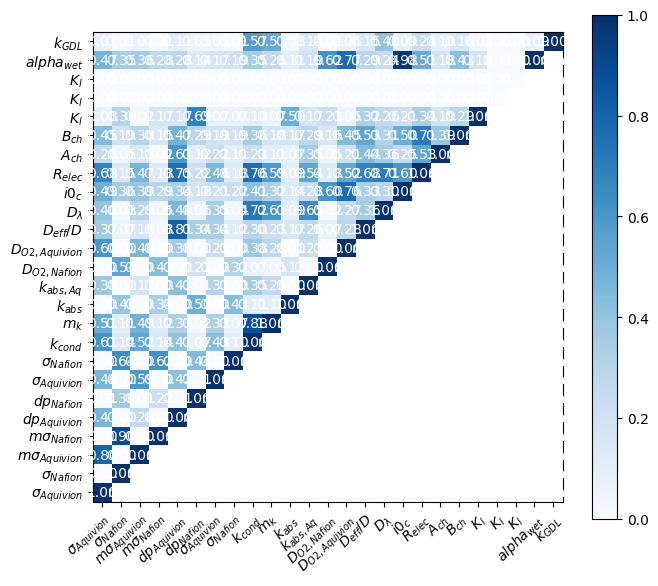

In [17]:
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(7,6))

plt.show()

In [18]:
sol, p_est = model.estimate(exp_res_list, t=0, print_iterations=True, popsize=40, ftol=1e-5)
model.p.update({param: v for param, v in zip(model.p_i_name, p_est)})

differential_evolution step 1: f(x)= 0.0029214608983767596
------------------------------
RMSE : 54.1 mV
AquivionD83-06-cl-proton-cond (1, 200) 4.86e+01
NafionLQ1115-cl-proton-cond (1, 200) 1.13e+02
AquivionD83-06-cl-proton-cond-exp (2, 4) 2.83e+00
NafionLQ1115-cl-proton-cond-exp (2, 4) 3.34e+00
AquivionD83-06-pore-diameter (1e-09, 2e-07) 1.45e-07
NafionLQ1115-pore-diameter (1e-09, 2e-07) 1.15e-07
AquivionD83-06-cl-o2-diff-exp (0.5, 2) 1.21e+00
NafionLQ1115-cl-o2-diff-exp (0.5, 2) 5.13e-01
NafionHP-conductivity-correction (0.5, 5) 4.76e+00
NafionHP-conductivity-exp (1, 2) 1.69e+00
Nafion-memb-abs-constant (1e-06, 0.0001) 1.87e-05
Aquivion-memb-abs-constant (1e-06, 0.0001) 9.42e-05
NafionLQ1115-o2-diff (1e-12, 1e-09) 9.54e-10
AquivionD83-06-o2-diff (1e-12, 1e-08) 5.95e-09
3M-Deff-ratio (0.15, 0.5) 3.44e-01
Nafion-memb-diff (1e-10, 1e-09) 7.53e-10
i0-c (1e-05, 0.001) 1.20e-04
elec-resistance (2e-06, 6e-06) 2.44e-06
A_ch (0, 2) 6.62e-01
B_ch (0, 2) 3.08e-01
Kabs (1e-13, 1e-11) 1.89e-13
Aq

KeyboardInterrupt: 

In [ ]:
'''------------------------------
differential_evolution step 193: f(x)= 3.98489192715642e-05
------------------------------
RMSE : 6.3 mV
AquivionD83-06-cl-proton-cond (1, 200) 1.20e+00
NafionLQ1115-cl-proton-cond (1, 200) 2.06e+00
AquivionD83-06-cl-proton-cond-exp (1, 4) 1.00e+00
NafionLQ1115-cl-proton-cond-exp (1, 4) 1.00e+00
AquivionD83-06-pore-diameter (1e-08, 2e-07) 3.62e-08
NafionLQ1115-pore-diameter (1e-08, 2e-07) 1.97e-07
AquivionD83-06-cl-o2-diff-exp (0.5, 2) 8.54e-01
NafionLQ1115-cl-o2-diff-exp (0.5, 2) 5.00e-01
NafionHP-conductivity-exp (1, 2) 1.15e+00
Nafion-memb-abs-constant (1e-06, 0.0001) 1.25e-06
Aquivion-memb-abs-constant (1e-06, 0.0001) 2.91e-06
NafionLQ1115-o2-diff (1e-12, 1e-09) 9.93e-10
AquivionD83-06-o2-diff (1e-12, 1e-08) 1.34e-09
3M-Deff-ratio (0.15, 0.5) 3.71e-01
Nafion-memb-diff (1e-10, 1e-09) 1.19e-10
elec-resistance (2e-06, 6e-06) 4.58e-06
A_ch (0.1, 2) 1.04e-01
B_ch (0.0001, 2) 7.68e-01
Kabs (1e-13, 1e-11) 2.98e-13
Aquivion-cl-K-abs (1e-14, 1e-11) 1.35e-14
Nafion-cl-K-abs (1e-14, 1e-11) 3.08e-14
wet-transition (0.0, 0.4) 2.65e-01
kth-gdl (0.03, 5) 1.80e+00
------------------------------'''

'------------------------------\ndifferential_evolution step 193: f(x)= 3.98489192715642e-05\n------------------------------\nRMSE : 6.3 mV\nAquivionD83-06-cl-proton-cond (1, 200) 1.20e+00\nNafionLQ1115-cl-proton-cond (1, 200) 2.06e+00\nAquivionD83-06-cl-proton-cond-exp (1, 4) 1.00e+00\nNafionLQ1115-cl-proton-cond-exp (1, 4) 1.00e+00\nAquivionD83-06-pore-diameter (1e-08, 2e-07) 3.62e-08\nNafionLQ1115-pore-diameter (1e-08, 2e-07) 1.97e-07\nAquivionD83-06-cl-o2-diff-exp (0.5, 2) 8.54e-01\nNafionLQ1115-cl-o2-diff-exp (0.5, 2) 5.00e-01\nNafionHP-conductivity-exp (1, 2) 1.15e+00\nNafion-memb-abs-constant (1e-06, 0.0001) 1.25e-06\nAquivion-memb-abs-constant (1e-06, 0.0001) 2.91e-06\nNafionLQ1115-o2-diff (1e-12, 1e-09) 9.93e-10\nAquivionD83-06-o2-diff (1e-12, 1e-08) 1.34e-09\n3M-Deff-ratio (0.15, 0.5) 3.71e-01\nNafion-memb-diff (1e-10, 1e-09) 1.19e-10\nelec-resistance (2e-06, 6e-06) 4.58e-06\nA_ch (0.1, 2) 1.04e-01\nB_ch (0.0001, 2) 7.68e-01\nKabs (1e-13, 1e-11) 2.98e-13\nAquivion-cl-K-abs (1

In [7]:
model.p.update({
'AquivionD83-06-cl-proton-cond': 120,
'NafionLQ1115-cl-proton-cond': 108,
'AquivionD83-06-cl-proton-cond-exp': 3.46e+00,
'NafionLQ1115-cl-proton-cond-exp': 3.46e+00,
'AquivionD83-06-pore-diameter': 1.30e-07,
'NafionLQ1115-pore-diameter': 13e-8,
'AquivionD83-06-cl-o2-diff-exp': 5.04e-01,
'NafionLQ1115-cl-o2-diff-exp': 5.04e-01, 
'NafionHP-conductivity-correction': 1.49e+00,
'NafionHP-conductivity-exp': 1.19e+00,
'Nafion-memb-abs-constant': 1.71e-4,
'Aquivion-memb-abs-constant': 9.79e-4,
'NafionLQ1115-o2-diff': 4.54e-09,
'AquivionD83-06-o2-diff': 4.98e-09,
'3M-Deff-ratio': 5.47e-01,
'Nafion-memb-diff':  58e-10,
'i0-c':  3.95e-04,
'elec-resistance':  4.39e-06,
'A_ch':  0.533,
'B_ch': 1.25e+00,
'Kabs':  4.3e-12,
'wet-transition':  3.48e-01,
'kth-gdl':  1.45e+01,})


In [8]:
exp_data = pd.read_csv(f'../data/garsany_et_al_2018/Garsany2018-gz.csv', sep=';', decimal=',')
exp_data = exp_data[exp_data.cell_id != 'GORE']
cells = exp_data.cell_id.unique()
for cell in cells: 
    exp_data.loc[exp_data.cell_id  == cell, 'case'] = exp_data.loc[exp_data.cell_id  == cell, ['T_stack', 'rh_ca', 'rh_an', 'p_ca_out']].sum(axis=1)
case_list = [1,2,3]
exp_data['case'] = exp_data['case'].map(dict(zip(exp_data['case'].unique(),case_list)))
exp_data = exp_data

13.560855314313041 11.112501899189173


<Figure size 640x480 with 0 Axes>

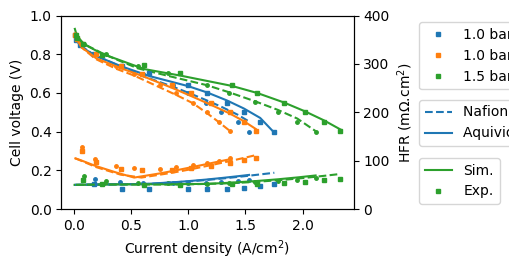

In [33]:
case_name = [
    
    'Nafion LSC - 1 bar - 50% RH', 
    'Nafion LSC - 1 bar - 100% RH', 
    'Nafion LSC - 1.5 bar - 100% RH', 
    'Aquivion SSC - 1 bar - 50% RH', 
    'Aquivion SSC - 1 bar - 100% RH', 
    
    'Aquivion SSC - 1.5 bar - 100% RH', 
   
]
labels, labels2 = [], []
fig1, ax1 = plt.subplots(1, figsize=(6.6,2.8))
ax2 = ax1.twinx()
RMSE_U = 0 
RMSE_HFR = 0
N_U = 0 
N_HFR = 0
for i_cell, cell in enumerate(['LSC Nafion', 'SSC Aquivion']): 
    for k, case in enumerate(case_list): 
        fuel_cell = create_fuel_cell(model.p, cell)
        U_sim = compute_ui_curve(fuel_cell, case)
        case_exp_data = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id == cell)]
        U_exp = case_exp_data['U'].values
        res_U = U_exp - U_sim
        
        
        l2, = ax1.plot(fuel_cell.current_density/1e4, U_exp, 'C{}'.format(k) + ('s' if i_cell == 1 else 'o'), markersize=2.5)
        l, = ax1.plot(fuel_cell.current_density/1e4, U_sim, 'C{}-'.format(k) + ('-' if i_cell == 0 else ''))
        labels.append(l)
        labels2.append(l2)
        #leg_RMSE = ax1.legend(title='RMSE', bbox_to_anchor=(1.7,1), loc='upper left')
        ax1.set_ylim(0,1)
        ax2.plot(fuel_cell.current_density/1e4, 1e7*fuel_cell.high_frequency_resistance(), 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case)
        ax2.plot(case_exp_data['i'].values, 1e7*case_exp_data['hfr'].values, 'C{}'.format(k) + ('s' if i_cell == 1 else 'o'), markersize=2.5)
        res_HFR = np.nan_to_num(fuel_cell.high_frequency_resistance() - case_exp_data['hfr'].values,0)
        RMSE_U += np.dot(res_U, res_U)
        RMSE_HFR += np.dot(res_HFR, res_HFR)
        N_U += len(res_U)
        N_HFR += len(res_HFR) - sum(np.isnan(case_exp_data['hfr'].values))
        ax2.set_ylim(0,400)
        plt.figure(3)
        # plt.plot(fuel_cell.current_density/1e4, fuel_cell.ca.bi, 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case, alpha=0.5 )
        # plt.plot(fuel_cell.current_density/1e4, fuel_cell.an.bi, 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case, alpha=0.5 )
        # plt.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.pe, 'C{}-'.format(k) + '-' if i_cell == 1 else '', label=case, alpha=0.5 )
RMSE_U = np.sqrt(RMSE_U / N_U)
RMSE_HFR = np.sqrt(RMSE_HFR/ N_HFR)
print(RMSE_U * 1e3, RMSE_HFR * 1e7)
plt.figure(1)
leg1 = ax1.legend(handles=labels2[3:], labels=['1.0 bar - 50% RH', '1.0 bar - 100% RH', '1.5 bar - 100% RH', ], bbox_to_anchor=(1.2,1), loc='upper left')
leg2 = ax1.legend(handles=(labels[0], labels[3]), labels=['Nafion LSC', 'Aquivion SSC'], bbox_to_anchor=(1.2,0.6), loc='upper left')
leg3 = ax1.legend(handles=(l, l2), labels=['Sim.', 'Exp.'], bbox_to_anchor=(1.2,0.3), loc='upper left')
#ax1.add_artist(leg_RMSE)
ax1.add_artist(leg1)
ax1.add_artist(leg2)
ax1.set_xlabel('Current density (A/cm$^2$)')
ax1.set_ylabel('Cell voltage (V)')
ax2.set_ylabel('HFR (m$\Omega$.cm$^2$)')
fig1.tight_layout()
fig1.savefig('garsany_2018_estimation.png', dpi=300, bbox_extra_artists=(leg1,), bbox_inches='tight')

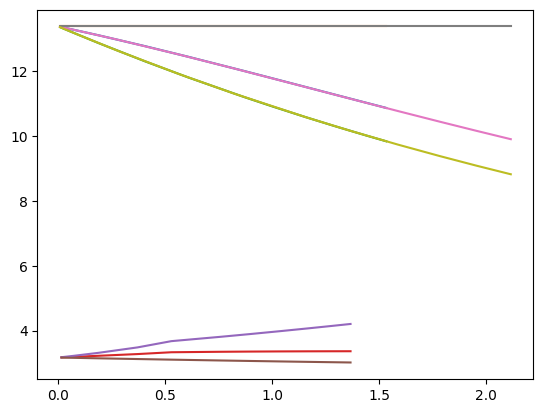

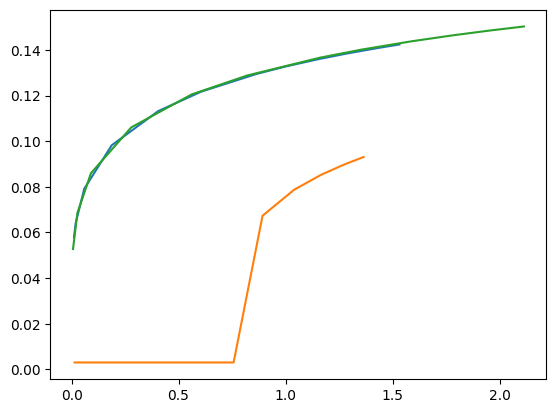

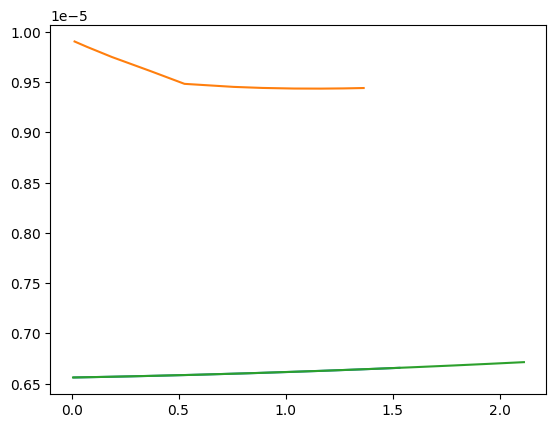

In [ ]:
for i_cell, cell in enumerate(['LSC Nafion']): 
    for k, case in enumerate([1,2,3]): 
        fuel_cell = create_fuel_cell(model.p, cell)
        U_sim = compute_ui_curve(fuel_cell, case)
        case_exp_data = exp_data.loc[np.logical_and(exp_data.case == case, exp_data.cell_id == cell)]
        U_exp = case_exp_data['U'].values
        res = U_exp - U_sim
        RMSE = np.sqrt(np.dot(res, res) / len(res)) * 1000
        
        plt.figure(1)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.water_content)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.ca.equiv_water_content)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.an.equiv_water_content)
        
        plt.figure(3)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.ca.gdl.water_saturation)
        plt.figure(2)
        plt.plot(fuel_cell.current_density/1e4, fuel_cell.high_frequency_resistance())
        #plt.plot(fuel_cell.current_density/1e4, fuel_cell.an.bi, 'C1-' + '-' if i_cell == 1 else '', label=case, alpha=1 )
       # plt.plot(fuel_cell.current_density/1e4, fuel_cell.membrane.pe, 'C2-'.format(k) + '-' if i_cell == 1 else '', label=case, alpha=1 )
